In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as mp
import seaborn as sb

In [ ]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.shape

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
for col in df.select_dtypes(include="object"):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3333/2308743177.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

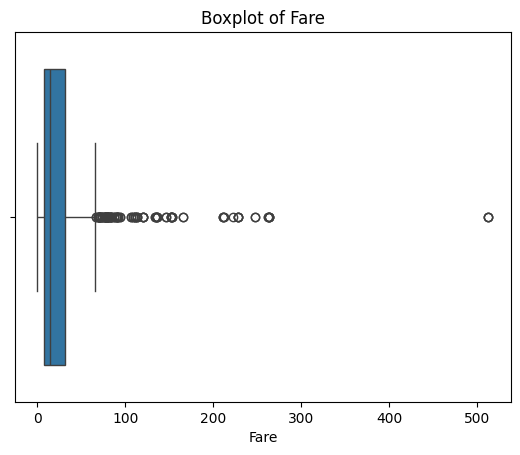

In [ ]:
sb.boxplot(x=df["Fare"])

mp.title("Boxplot of Fare")

mp.show()

In [ ]:
Q1 = df["Fare"].quantile(0.25)

Q3 = df["Fare"].quantile(0.75)

print(Q1)

print(Q3)

7.9104
31.0


In [ ]:
IQR = Q3 - Q1

print(IQR)

23.0896


In [ ]:
lower_limit = Q1 - (1.5 * IQR)

upper_limit = Q3 + (1.5 * IQR)

print(lower_limit)

print(upper_limit)

-26.724
65.6344


In [ ]:
outliers = df[(df["Fare"] < lower_limit) | (df["Fare"] > upper_limit)]

outliers.shape

(116, 12)

In [ ]:
df = df[(df["Fare"] >= lower_limit) &
        (df["Fare"] <= upper_limit)]

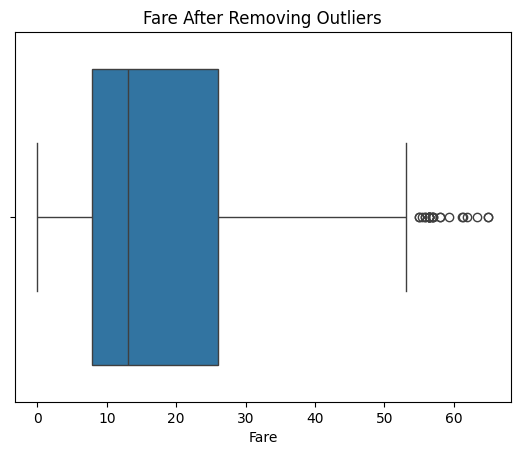

In [ ]:
sb.boxplot(x=df["Fare"])

mp.title("Fare After Removing Outliers")

mp.show()

In [ ]:
df[df["Age"] > 30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,B96 B98,S
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,B96 B98,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,B96 B98,Q


In [ ]:
df[df["Sex"] == "female"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,B96 B98,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,B96 B98,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.000000,1,1,PP 9549,16.7000,G6,S
...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.000000,0,1,230433,26.0000,B96 B98,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.000000,0,0,7552,10.5167,B96 B98,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,B96 B98,Q
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S


In [ ]:
df[df["Pclass"] == 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,B96 B98,C
...,...,...,...,...,...,...,...,...,...,...,...,...
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [ ]:
df[(df["Sex"] == "female") &
   (df["Pclass"] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.000000,0,0,113783,26.5500,C103,S
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.000000,0,2,11752,26.2833,D47,S
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,29.699118,0,1,113505,55.0000,E33,S
177,178,0,1,"Isham, Miss. Ann Elizabeth",female,50.000000,0,0,PC 17595,28.7125,C49,C
194,195,1,1,"Brown, Mrs. James Joseph (Margaret Tobin)",female,44.000000,0,0,PC 17610,27.7208,B4,C
309,310,1,1,"Francatelli, Miss. Laura Mabel",female,30.000000,0,0,PC 17485,56.9292,E36,C
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.000000,0,1,111361,57.9792,B18,C
356,357,1,1,"Bowerman, Miss. Elsie Edith",female,22.000000,0,1,113505,55.0000,E33,S
383,384,1,1,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.000000,1,0,113789,52.0000,B96 B98,S


In [ ]:
df.sort_values(by="Age")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,B96 B98,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,B96 B98,S
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,B96 B98,C
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,B96 B98,C
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
116,117,0,3,"Connors, Mr. Patrick",male,70.50,0,0,370369,7.7500,B96 B98,Q
96,97,0,1,"Goldschmidt, Mr. George B",male,71.00,0,0,PC 17754,34.6542,A5,C
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,B96 B98,C
851,852,0,3,"Svensson, Mr. Johan",male,74.00,0,0,347060,7.7750,B96 B98,S


In [ ]:
df.sort_values(by="Fare", ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
754,755,1,2,"Herman, Mrs. Samuel (Jane Laver)",female,48.000000,1,2,220845,65.0000,B96 B98,S
615,616,1,2,"Herman, Miss. Alice",female,24.000000,1,2,220845,65.0000,B96 B98,S
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.000000,0,1,PC 17759,63.3583,D10 D12,C
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.000000,0,1,113509,61.9792,B30,C
155,156,0,1,"Williams, Mr. Charles Duane",male,51.000000,0,1,PC 17597,61.3792,B96 B98,C
...,...,...,...,...,...,...,...,...,...,...,...,...
179,180,0,3,"Leonard, Mr. Lionel",male,36.000000,0,0,LINE,0.0000,B96 B98,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,29.699118,0,0,239853,0.0000,B96 B98,S
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.000000,0,0,112050,0.0000,A36,S
822,823,0,1,"Reuchlin, Jonkheer. John George",male,38.000000,0,0,19972,0.0000,B96 B98,S


In [ ]:
df.groupby("Pclass")["Age"].mean()

,Age
Pclass,
1,39.463220
2,30.053186
3,26.355591


In [ ]:
df.groupby("Pclass")["Fare"].mean()

,Fare
Pclass,
1,37.052978
2,19.186266
3,12.867449


In [ ]:
df.groupby("Sex")["Survived"].sum()

,Survived
Sex,
female,168
male,95


In [ ]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.508929
2,0.486034
3,0.245868


In [ ]:
df["Survived"].sum()

np.int64(263)

In [ ]:
(df["Survived"].mean()) * 100

np.float64(33.935483870967744)

In [ ]:
df[df["Sex"] == "male"]["Survived"].mean() * 100

np.float64(17.890772128060263)

In [ ]:
df[df["Sex"] == "female"]["Survived"].mean() * 100

np.float64(68.85245901639344)

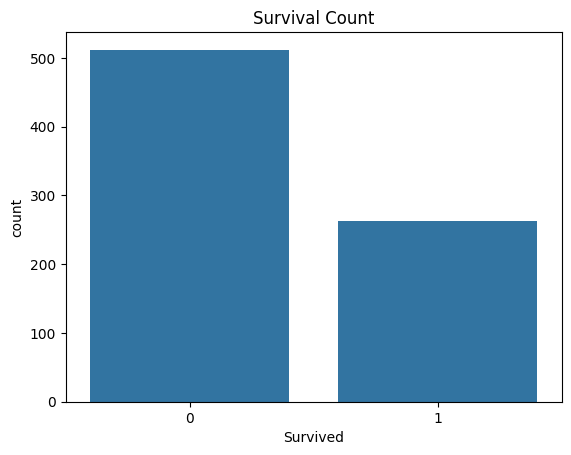

In [ ]:
sb.countplot(x="Survived", data=df)

mp.title("Survival Count")

mp.show()

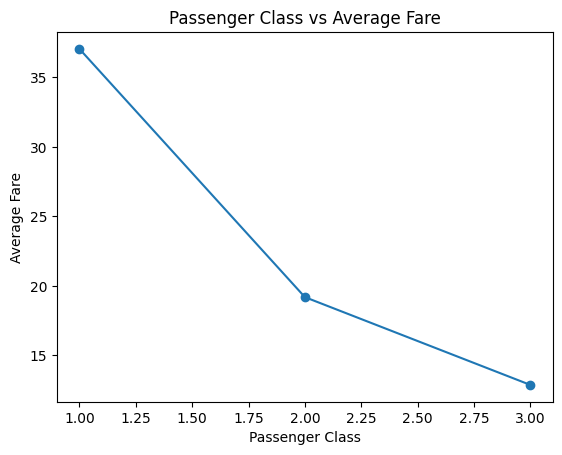

In [ ]:
line_data = df.groupby("Pclass")["Fare"].mean()

mp.plot(line_data.index,
        line_data.values,
        marker="o")

mp.title("Passenger Class vs Average Fare")

mp.xlabel("Passenger Class")

mp.ylabel("Average Fare")

mp.show()

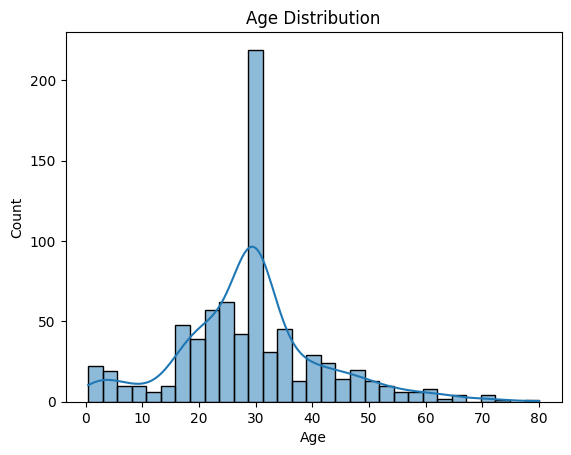

In [ ]:
sb.histplot(df["Age"], kde=True)

mp.title("Age Distribution")

mp.show()

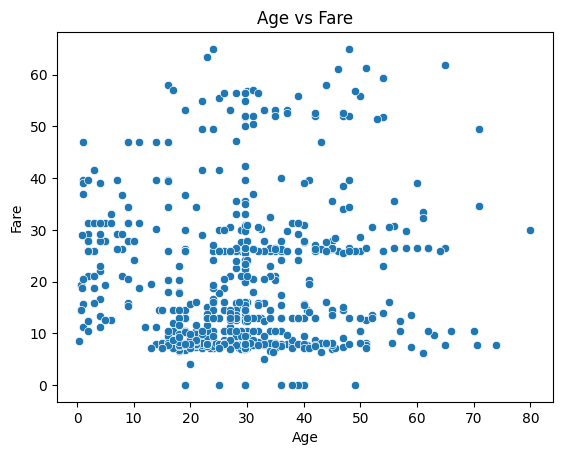

In [ ]:
sb.scatterplot(x="Age",
               y="Fare",
               data=df)

mp.title("Age vs Fare")

mp.show()